In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

****load a dataset from kaggle:"https://www.kaggle.com/datasets/shivamb/netflix-shows?utm_source=chatgpt.com"****

In [3]:
data=pd.read_csv("netflix_titles.csv")
data.shape


(8807, 12)

In [4]:
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
data.info()
data.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

****handile a missing value****

In [6]:
data["director"]=data["director"].fillna("unknown")
data["cast"]=data["cast"].fillna("unknown")
data["country"]=data["country"].fillna("unknown")
data["rating"]=data["rating"].fillna(data["rating"].mode()[0])


****Drop a two column (date_added,duration)****

In [7]:
data.dropna(subset=['date_added',"duration"], inplace=True)


In [8]:
data.isna().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

****convert a type into two "movie" & "TV show"and plot the types****

In [9]:
data["type"].value_counts()

type
Movie      6128
TV Show    2666
Name: count, dtype: int64

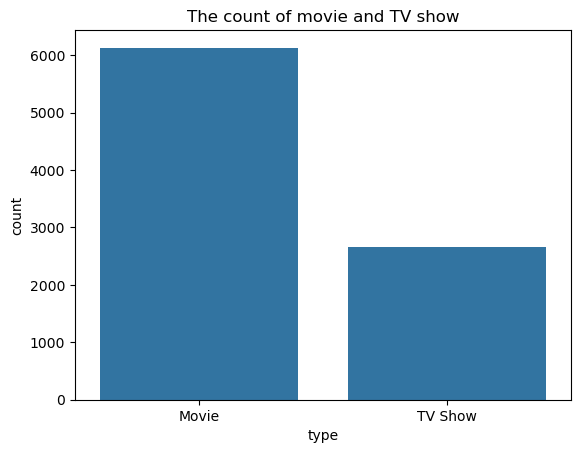

In [10]:
sns.countplot(
    x="type",
    data=data
)
plt.title("The count of movie and TV show")
plt.show()

****convert a data into year wise how many movies was out  and plot the value****

In [11]:
year_count=data["release_year"].value_counts().sort_index()
year_count

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1031
2018    1146
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64

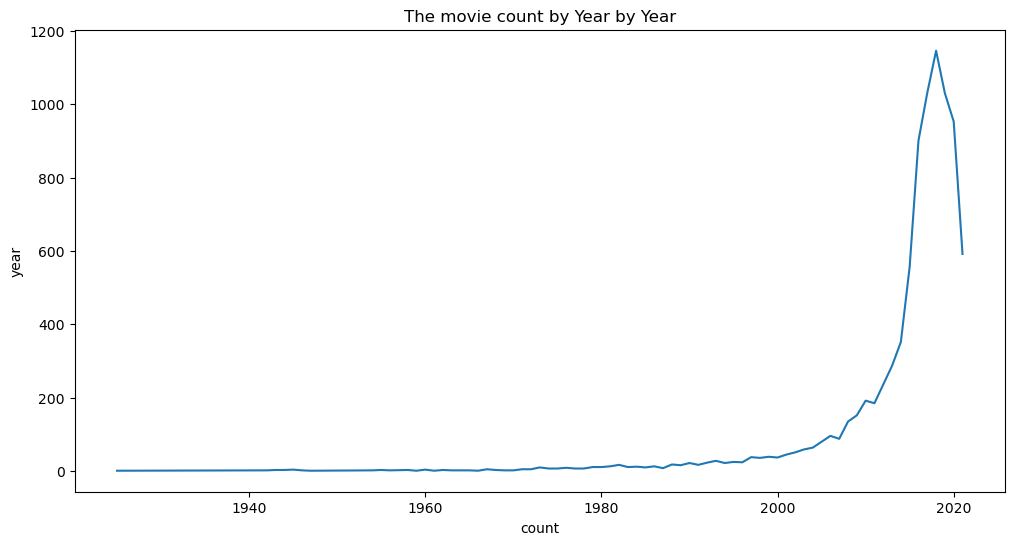

In [12]:
plt.figure(figsize=(12,6))
plt.plot(year_count)
plt.title("The movie count by Year by Year")
plt.xlabel("count")
plt.ylabel("year")
plt.show()

****split a data into gerner wise and plot a data****

In [13]:
gerner=data["listed_in"].str.split(",",expand=True)
gerner

,0,1,2
0,Documentaries,None,None
1,International TV Shows,TV Dramas,TV Mysteries
2,Crime TV Shows,International TV Shows,TV Action & Adventure
3,Docuseries,Reality TV,None
4,International TV Shows,Romantic TV Shows,TV Comedies
...,...,...,...
8802,Cult Movies,Dramas,Thrillers
8803,Kids' TV,Korean TV Shows,TV Comedies
8804,Comedies,Horror Movies,None
8805,Children & Family Movies,Comedies,None


In [14]:
all_gerner=gerner.stack()
top_gerner=all_gerner.value_counts().head(10)

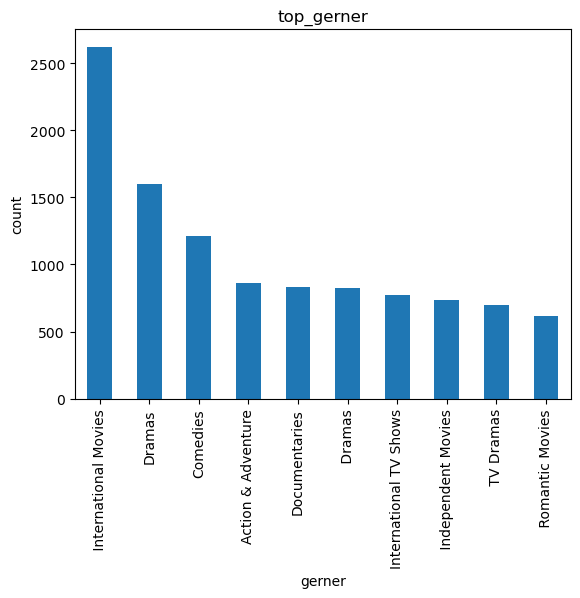

In [15]:
top_gerner.plot(kind="bar")
plt.title("top_gerner")
plt.xlabel("gerner")
plt.ylabel("count")
plt.show()

****split only movie row  from the data****

In [16]:
movies=data[data["type"]=="Movie"]
movies.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",unknown,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...


****convert a object into int (duration to duration_num)  and polt the data****

In [17]:
movies.loc[:,'duration_num'] = movies['duration'].str.extract('(\d+)')

movies.loc[:,'duration_num'] = movies['duration_num'].astype(int)

C:\Users\vishn\AppData\Local\Temp\ipykernel_20556\1970676702.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies.loc[:,'duration_num'] = movies['duration'].str.extract('(\d+)')


(array([1.470e+02, 4.500e+02, 2.095e+03, 2.569e+03, 6.920e+02, 1.440e+02,
        2.200e+01, 6.000e+00, 2.000e+00, 1.000e+00]),
 array([  3. ,  33.9,  64.8,  95.7, 126.6, 157.5, 188.4, 219.3, 250.2,
        281.1, 312. ]),
 <BarContainer object of 10 artists>)

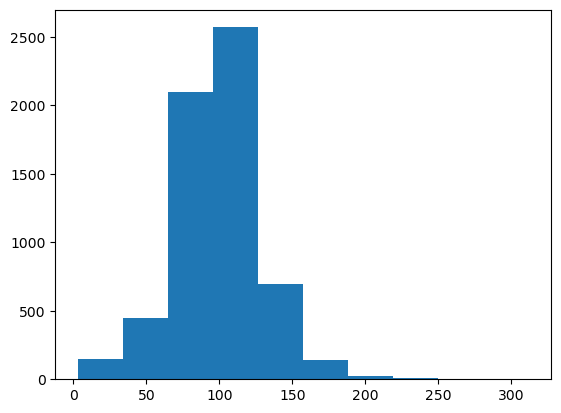

In [18]:
plt.Figure(figsize=(10,5))
plt.hist(
    movies["duration_num"]
)

****find a max movie released year and plot a top 10 year****

In [22]:
top_years = data['release_year'].value_counts().head(10)

print(top_years)

release_year
2018    1146
2017    1031
2019    1030
2020     953
2016     901
2021     592
2015     557
2014     352
2013     287
2012     236
Name: count, dtype: int64


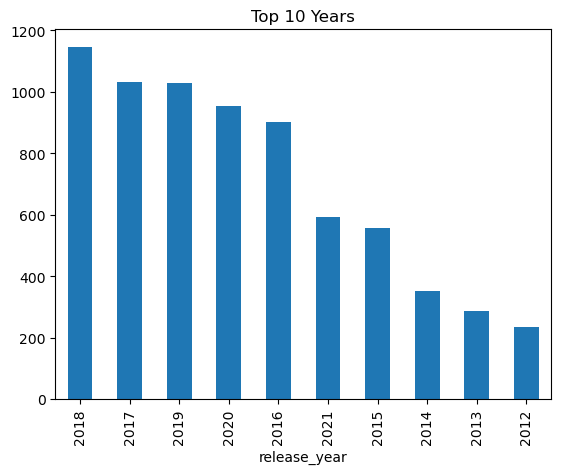

In [23]:
top_years.plot(kind='bar')
plt.title('Top 10 Years')
plt.show()

****Plot a heatmap****

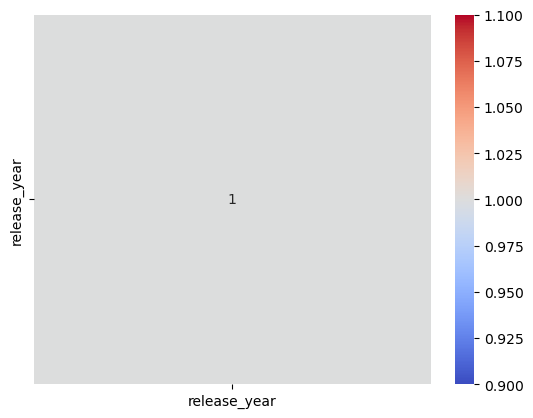

In [21]:
num_col = data.select_dtypes(include=np.number)
sns.heatmap(
    num_col.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()

****1)Movies are more common than TV Shows on Netflix.****

****2)Netflix content grew rapidly after 2015.****

****3)Drama, International Movies, and Comedy are among the top genres.****

****4)Most movies have runtimes between 80–120 minutes.****

****5)Recent years have significantly more content compared to older years.****